# Урок 11. Теория информации

> **Зачем это нужно:** энтропия и KL-дивергенция — это язык, на котором описывают многоклассовую классификацию, generative-модели, дистилляцию, VAE и обучение с подкреплением.

---

## 1. Что такое энтропия?

**Энтропия** в теории информации — это **мера неопределенности** или случайности источника данных. Чем хаотичнее и непредсказуемее система, тем выше её энтропия.

С точки зрения передачи данных, энтропия показывает минимальное среднее количество бит, необходимое для кодирования одного сообщения.

---

### 2. Формула энтропии Шеннона

Для дискретной случайной величины $X$ с возможными исходами $x_1, x_2, \dots, x_n$ и их вероятностями $P(x_i)$ формула выглядит следующим образом:

$$H(X) = -\sum_{i=1}^{n} P(x_i) \log_b P(x_i)$$

*   **$H(X)$** — энтропия системы.
*   **$P(x_i)$** — вероятность наступления события $x_i$.
*   **$\log_b$** — логарифм по основанию $b$.
    *   Если $b=2$, энтропия измеряется в **битах** (или шеннонах).
    *   Если используется натуральный логарифм ($b=e$), то единица измерения — **нат**.

> **Интуиция:** Если событие абсолютно гарантировано ($P=1$), то $\log(1) = 0$, и неопределенность отсутствует (энтропия равна 0). Если все исходы равновероятны, неопределенность системы становится максимальной.

---

### 3. Применение энтропии в Machine Learning (ML)

В машинном обучении концепты теории информации используются для оценки качества моделей, разделения данных и оптимизации алгоритмов. Ниже приведены главные сферы применения.

#### 3.1 Функция потерь: Кросс-энтропия (Cross-Entropy Loss)
Это стандартная функция потерь для задач классификации (например, распознавание лиц или детекция спама).
*   **Принцип работы:** Измеряет разницу между истинным распределением вероятностей (правильный класс) и предсказанным моделью.
*   **Цель обучения:** Модель обучается так, чтобы минимизировать кросс-энтропию. Чем ближе предсказание к реальности, тем ближе лосс к нулю.

#### 3.2 Построение Деревьев Решений (Decision Trees)
При создании деревьев (алгоритмы вроде ID3, C4.5) модель должна решать, по какому признаку эффективнее всего разделить данные в текущем узле.
*   **Прирост информации (Information Gain):** Измеряется как разница между энтропией системы до разделения и после него.
*   **Цель алгоритма:** Выбирается тот признак, который сильнее всего снижает общую энтропию, делая подгруппы данных максимально однородными.

#### 3.3 Расстояние Кульбака — Лейблера (KL-Divergence)
Это модификация энтропии, которая измеряет, насколько одно распределение вероятностей отличается от другого.
*   **Сфера применения:** В генеративных моделях (VAE — вариационные автокодировщики, GAN) для того, чтобы заставить скрытое пространство модели соответствовать стандартному распределению (например, Гауссовскому), а также в алгоритме t-SNE для снижения размерности данных.

#### 3.4 Максимизация энтропии в обучении с подкреплением (Reinforcement Learning)
В некоторых алгоритмах RL (например, SAC — Soft Actor-Critic) к функции вознаграждения агента добавляют штраф за низкую энтропию действий.
*   **Цель алгоритма:** Это стимулирует агента выбирать более разнообразные действия (исследовать среду, **exploration**), вместо того чтобы зацикливаться на одной знакомой стратегии (**exploitation**).

---

In [1]:
import numpy as np

def entropy(p):
    p = np.asarray(p)
    return -np.sum(p * np.log(p + 1e-12))

print(entropy([0.5, 0.5]))   # ≈ 0.693
print(entropy([0.99, 0.01])) # ≈ 0.056
print(entropy([0.25]*4))     # log(4)

0.6931471805579453
0.05600153435284737
1.3862943611158907


---
## 2. Кросс-энтропия (Cross-Entropy) в Machine Learning

**Кросс-энтропия** — это метрика из теории информации, которая измеряет разницу между двумя распределениями вероятностей. В машинном обучении она используется в качестве функции потерь (Loss Function) для задач классификации. Она показывает, насколько предсказания модели отличаются от реальных (истинных) меток.

---

### 1. Математическая формула (Многоклассовая классификация)

Для дискретного случая кросс-энтропия между истинным распределением $P$ и предсказанным распределением $Q$ рассчитывается по формуле:

$$H(P, Q) = -\sum_{i=1}^{n} P(x_i) \log Q(x_i)$$

Где:
* **$P(x_i)$** — истинная вероятность принадлежности объекта к классу $i$. В задачах классификации (при использовании One-Hot Encoding) она равна `1` для правильного класса и `0` для всех остальных.
* **$Q(x_i)$** — предсказанная моделью вероятность для класса $i$ (значение от 0 до 1, обычно выдаваемое функцией `Softmax`).
* **$n$** — общее количество классов.

---

### 2. Бинарная кросс-энтропия (Binary Cross-Entropy / Log Loss)

Если в задаче всего два класса (например, *спам / не спам*), формула упрощается. Модель предсказывает одну вероятность $q$ для целевого класса. Истинная метка $p$ принимает значение либо `1`, либо `0`.

$$BCE = - \big[ p \log(q) + (1 - p) \log(1 - q) \big]$$

### Логика работы формулы:
* **Если истинный класс $p = 1$:** Правая часть обнуляется, остается $-1 \cdot \log(q)$. Если модель угадала ($q \approx 1$), то $\log(1) = 0$ — штраф минимален. Если модель сильно ошиблась ($q \approx 0$), то $\log(0) \to -\infty$, и общий лосс устремляется в бесконечность.
* **Если истинный класс $p = 0$:** Левая часть обнуляется, остается $-1 \cdot \log(1 - q)$. Штраф стремительно растет, если предсказанное значение $q$ приближается к единице.

---

### 3. Зачем кросс-энтропия нужна в Machine Learning?

### Интуитивное наказание за уверенные ошибки
Использование логарифма делает кросс-энтропию крайне чувствительной к сильным промахам. 
* Если модель ошибается, но «сомневается» (выдает вероятность 0.4 вместо 1), штраф будет умеренным.
* Если модель **абсолютно уверена** в неверном ответе (выдает вероятность 0.001 для правильного класса), кросс-энтропия мгновенно выдает **огромный штраф**. Это заставляет алгоритм быстрее корректировать веса.

### Идеальная синергия с Softmax
На выходном слое нейросетей классификации обычно стоит активация `Softmax`, превращающая сырые числа (логиты) в вероятности. При взятии производной от кросс-энтропии по логитам получается удивительно простая формула градиента: 

$$\frac{\partial L}{\partial z_i} = Q(x_i) - P(x_i)$$

Это избавляет нейросеть от проблемы «затухания градиентов» на этапе старта обучения и обеспечивает быструю и стабильную сходимость модели.


In [2]:
def cross_entropy(p, q):
    p, q = np.asarray(p), np.asarray(q)
    return -np.sum(p * np.log(q + 1e-12))


**В ML `p` — это правда (one-hot), `q` — предсказание модели.** Минимизация cross-entropy = подстраивание `q` под `p`.

---
# 3. Дивергенция Кульбака — Лейблера (Kullback-Leibler Divergence / KL-Divergence)

**Дивергенция Кульбака — Лейблера (KL-дивергенция)** — это метрика из теории информации, которая измеряет степень различия между двумя распределениями вероятностей: истинным (эталонным) распределением $P$ и приближенным распределением $Q$.

*Интуитивное определение:* Она показывает, **сколько информации (в битах или натах) мы потеряем**, если будем кодировать сообщения из распределения $P$, ошибочно предполагая, что они подчиняются распределению $Q$.

---

## 1. Математическая формула и связь с энтропией

Для дискретных распределений KL-дивергенция рассчитывается по формуле:

$$D_{KL}(P \parallel Q) = \sum_{i=1}^{n} P(x_i) \log \left( \frac{P(x_i)}{Q(x_i)} \right)$$

Используя свойство логарифма ($\log \frac{A}{B} = \log A - \log B$), формулу можно разбить на две части:

$$D_{KL}(P \parallel Q) = \sum_{i=1}^{n} P(x_i) \log P(x_i) - \sum_{i=1}^{n} P(x_i) \log Q(x_i)$$

Если присмотреться к компонентам, то мы увидим связь с **энтропией Шеннона** $H(P)$ - собственная энтропия истинного распределения $P$ и **кросс-энтропией** $H(P, Q)$ - показывает, сколько бит нужно, если использовать неверное распределение $Q$:

$$D_{KL}(P \parallel Q) = H(P, Q) - H(P)$$

> **Вывод:** KL-дивергенция — это просто **избыточная энтропия** (штраф), которую мы получаем из-за того, что наше предсказанное распределение $Q$ отличается от истинного распределения $P$.

---

## 2. Ключевые свойства KL-дивергенции

* **Неотрицательность:** $D_{KL}(P \parallel Q) \ge 0$ всегда (согласно неравенству Гиббса).
* **Условие равенства нулю:** $D_{KL}(P \parallel Q) = 0$ тогда и только тогда, когда распределения полностью идентичны ($P = Q$).
* **Несимметричность:** Направление сравнения имеет критическое значение:
  $$D_{KL}(P \parallel Q) \neq D_{KL}(Q \parallel P)$$
  Из-за отсутствия симметрии KL-дивергенция является *расхождением*, а не математической дистанцией (метрикой) в привычном понимании.

---

## 3. Применение KL-дивергенции в Machine Learning

### Вариационные автокодировщики (VAE)
В генеративных моделях VAE нейросеть сжимает данные в скрытое (латентное) пространство. Чтобы из этого пространства можно было генерировать реалистичные новые объекты, скрытые переменные должны подчиняться стандартному нормальному распределению $\mathcal{N}(0, I)$.
* **Роль KL:** Дивергенция добавляется в функцию потерь (Loss) как регуляризатор. Она штрафует модель, если распределение латентных векторов начинает сильно отклоняться от идеальной формы Гауссовского распределения.

### Алгоритм t-SNE (Снижение размерности)
t-SNE используется для визуализации сложных многомерных данных на плоскости (2D) или в 3D.
* **Роль KL:** Алгоритм вычисляет сходство точек в исходном пространстве (распределение $P$) и их сходство на плоскости после сжатия (распределение $Q$). Затем он перемещает точки на карте так, чтобы **минимизировать KL-дивергенцию** между $P$ и $Q$, сохраняя локальную структуру данных и кластеры.

### Дистилляция знаний (Knowledge Distillation)
Это процесс, при котором огромная и точная нейросеть («учитель») передает свои знания маленькой и быстрой модели («ученику»).
* **Роль KL:** Маленькая модель учится воспроизводить не просто финальные жесткие ответы (0 или 1), а в точности повторять «мягкое» распределение вероятностей, выдаваемое большой моделью. KL-дивергенция используется как Loss-функция для сближения распределений выходов ученика и учителя.


---
# 4. Связь Кросс-энтропии и Меода Максимального Правдоподобия (MLE)

В машинном обучении минимизация функции потерь Кросс-энтропии (Cross-Entropy Loss) математически **эквивалентна** максимизации правдоподобия модели (MLE — Maximum Likelihood Estimation). Когда мы обучаем классификатор с помощью градиентного спуска по кросс-энтропии, мы на самом деле ищем MLE-оценку параметров этой модели.

Ниже приведено строгое математическое доказательство этой связи.

---

## Шаг 1. Определение через метод максимального правдоподобия (MLE)

Пусть наш датасет состоит из $N$ независимых одинаково распределенных объектов: $(x_1, y_1), (x_2, y_2), \dots, (x_N, y_N)$, где $x_i$ — признаки, а $y_i$ — истинные метки классов. 

У нас есть параметрическая модель (например, логистическая регрессия или нейросеть) с весами $\theta$, которая предсказывает вероятность классов: $q(y_i \mid x_i; \theta)$.

Функция правдоподобия (Likelihood) для всей выборки — это совместная вероятность увидеть данные метки классов при текущих параметрах $\theta$. Так как объекты независимы, их вероятности перемножаются:

$$L(\theta) = \prod_{i=1}^{N} q(y_i \mid x_i; \theta)$$

Чтобы упростить оптимизацию и избежать численного зануления произведения, возьмем натуральный логарифм от обеих частей. Это превратит произведение в сумму и даст нам **функцию логарифмического правдоподобия (Log-Likelihood)**:

$$\log L(\theta) = \sum_{i=1}^{N} \log q(y_i \mid x_i; \theta)$$

Цель метода MLE — найти параметры $\theta$, которые максимизируют это выражение:

$$\theta_{MLE} = \arg\max_{\theta} \sum_{i=1}^{N} \log q(y_i \mid x_i; \theta)$$

Так как алгоритмы оптимизации в ML (например, градиентный спуск) минимизируют ошибку, мы меняем знак выражения на противоположный. Максимизация логарифмического правдоподобия превращается в **минимизацию Отрицательного Логарифмического Правдоподобия (NLL — Negative Log-Likelihood)**:

$$\theta_{MLE} = \arg\min_{\theta} \left( -\sum_{i=1}^{N} \log q(y_i \mid x_i; \theta) \right)$$

---

## Шаг 2. Определение через Кросс-энтропию

Теперь посмотрим на задачу с точки зрения теории информации. Представим истинное распределение вероятностей для каждого объекта $i$ как вектор One-Hot Encoding, где вероятность правильного класса $y_i$ равна `1`, а всех остальных классов — `0`. Обозначим это истинное распределение как $p(j \mid x_i)$, где $j$ — индекс класса.

Формула кросс-энтропии для всей выборки из $N$ объектов (усредненная по количеству объектов) выглядит так:

$$H(P, Q) = -\frac{1}{N} \sum_{i=1}^{N} \sum_{j=1}^{M} p(j \mid x_i) \log q(j \mid x_i; \theta)$$

Где $M$ — общее количество классов. 

Поскольку истинное распределение $p(j \mid x_i)$ равно нулю для всех классов, кроме одного правильного ($j = y_i$), внутренняя сумма по $j$ «схлопывается». В ней остается только одно слагаемое, где $p(y_i \mid x_i) = 1$:

$$H(P, Q) = -\frac{1}{N} \sum_{i=1}^{N} 1 \cdot \log q(y_i \mid x_i; \theta) = -\frac{1}{N} \sum_{i=1}^{N} \log q(y_i \mid x_i; \theta)$$

---

## Шаг 3. Сопоставление и Итог

Сравним целевые функции для поиска оптимальных параметров $\theta$:

1. **Через MLE (минимизация NLL):**  
   $$\arg\min_{\theta} \left( -\sum_{i=1}^{N} \log q(y_i \mid x_i; \theta) \right)$$
2. **Через Кросс-энтропию:**  
   $$\arg\min_{\theta} \left( -\frac{1}{N} \sum_{i=1}^{N} \log q(y_i \mid x_i; \theta) \right)$$

Множитель $\frac{1}{N}$ является константой по отношению к оптимизируемым параметрам $\theta$. Это значит, что он изменяет масштаб функции потерь, но никак не влияет на положение точки минимума.

> **Вывод:** Минимизация кросс-энтропии и максимизация правдоподобия (MLE) математически эквивалентны и приводят к абсолютно одинаковым весам модели. Cross-Entropy Loss в задачах классификации — это и есть среднее отрицательное логарифмическое правдоподобие (NLL) выборки.


---
# 5. Взаимная информация (Mutual Information / MI)

**Взаимная информация (Mutual Information)** — это метрика из теории информации, которая измеряет количество информации, содержащееся в одной случайной величине относительно другой. 

*Интуитивное определение:* Она показывает, **насколько уменьшается неопределенность** относительно переменной $X$, если нам становится известна переменная $Y$ (и наоборот).

В отличие от классического коэффициента корреляции Пирсона, который видит только линейные связи, взаимная информация способна улавливать **любые сложные нелинейные зависимости** между переменными.

---

## 1. Математическая формула и связь с энтропией

Для двух дискретных случайных величин $X$ и $Y$ взаимная информация рассчитывается через их совместное распределение вероятностей $P(x, y)$ и маргинальные (индивидуальные) распределения $P(x)$ и $P(y)$:

$$I(X; Y) = \sum_{x \in X} \sum_{y \in Y} P(x, y) \log \left( \frac{P(x, y)}{P(x)P(y)} \right)$$

Взаимную информацию можно элегантно выразить через уже изученные концепты энтропии и KL-дивергенции:

### А. Через условную энтропию
$$I(X; Y) = H(X) - H(X \mid Y)$$
$$I(X; Y) = H(Y) - H(Y \mid X)$$
*Интуиция:* Из общей неопределенности величины $X$ ($H(X)$) мы вычитаем ту неопределенность, которая осталась после того, как мы узнали $Y$ ($H(X \mid Y)$). Разница — это то чистая информация, которую $Y$ несет о $X$.

### Б. Через объединение энтропий
$$I(X; Y) = H(X) + H(Y) - H(X, Y)$$
Где $H(X, Y)$ — совместная энтропия двух систем.

### В. Через KL-дивергенцию
$$I(X; Y) = D_{KL}\big(P(x, y) \parallel P(x)P(y)\big)$$
*Интуиция:* Взаимная информация измеряет, насколько далеко реальное совместное распределение $P(x,y)$ (где зависимость существует) находится от гипотетического распределения $P(x)P(y)$, в котором величины $X$ и $Y$ принимаются за абсолютно независимые.

---

## 2. Ключевые свойства Mutual Information

* **Симметричность:** Информация взаимна: $I(X; Y) = I(Y; X)$. Узнать о $X$ через $Y$ — это то же самое, что узнать о $Y$ через $X$.
* **Неотрицательность:** $I(X; Y) \ge 0$ всегда.
* **Условие равенства нулю:** $I(X; Y) = 0$ тогда и только тогда, когда $X$ и $Y$ **полностью независимы** друг от друга.

---

## 3. Применение Mutual Information в Machine Learning

### Отбор признаков (Feature Selection)
В больших датасетах часто присутствует много избыточных признаков или случайного шума, замедляющего обучение моделей.
* **Роль MI:** Рассчитывается взаимная информация между каждым отдельным признаком $X_i$ и целевой переменной (таргетом) $Y$. Признаки с высоким значением $I(X_i; Y)$ оставляют для обучения, так как они содержат много полезных данных для предсказания. Признаки с нулевой или околонулевой MI отсекаются.

### Оценка качества кластеризации (Adjusted Mutual Information — AMI)
При кластеризации («обучении без учителя») у моделей нет жестких правильных ответов, но для валидации алгоритма у нас может быть истинная разметка классов.
* **Роль MI:** Метрика AMI измеряет взаимную информацию между распределением объектов по предсказанным кластерам и их реальным классам. Она скорректирована с учетом случайного угадывания. Значение, близкое к `1`, говорит о точном совпадении структуры.

### Обучение представлений и контролируемая генерация (InfoGAN)
В стандартных генеративно-состязательных сетях (GAN) случайный вектор шума на входе никак не контролирует конкретные свойства объекта (например, наклон или толщину линий при генерации цифр).
* **Роль MI:** В модели **InfoGAN** часть входного вектора выделяют под скрытые коды управления $c$ (стиль, наклон, размер). В функцию потерь добавляется регулярный штраф, который максимизирует взаимную информацию $I(c; G(z, c))$ между этим скрытым кодом $c$ и сгенерированным изображением $G(z, c)$. Это заставляет нейросеть менять конкретные визуальные свойства картинки строго в зависимости от изменения кода.


---
# 6. Дифференциальная энтропия (Differential Entropy)

**Дифференциальная энтропия** — это расширение концепции энтропии Шеннона на случай **непрерывных случайных величин** (таких как рост человека, температура, физические сигналы или непрерывные веса в слоях нейросети). 

Несмотря на визуальное сходство формул, дифференциальная энтропия имеет принципиальные математические отличия от дискретной. Она измеряет не абсолютную неопределенность, а **относительный разброс (объем) распределения вероятностей**.

---

## 1. Математическая формула

Для непрерывной случайной величины $X$ с плотностью распределения вероятностей $f(x)$ дифференциальная энтропия рассчитывается через интеграл:

$$h(X) = -\int_{-\infty}^{+\infty} f(x) \log f(x) \, dx$$

* Дифференциальная энтропия традиционно обозначается строчной буквой **$h(X)$**, в отличие от дискретной энтропии $H(X)$.
* Единицы измерения зависят от основания логарифма: если используется натуральный логарифм ($\log_e$), она измеряется в **натах**, если двоичный ($\log_2$) — в **битах**.

---

## 2. Важные и парадоксальные свойства

Дифференциальную энтропию нельзя напрямую интерпретировать как «количество информации». Из-за перехода от дискретного суммирования к непрерывному интегрированию она приобретает специфические свойства:

* **Может быть отрицательной:** В отличие от дискретной энтропии ($H(X) \ge 0$), значение $h(X)$ способно принимать отрицательные значения.  
  *Пример:* Для равномерного распределения на узком отрезке от $0$ до $0.5$ плотность $f(x) = 2$. Логарифм $\log(2) > 0$, а из-за знака минус перед интегралом мы получим отрицательную энтропию. Это указывает на высокую концентрацию вероятности.
* **Зависит от масштаба:** Она не инвариантна к изменению масштаба (замене координат). Если мы умножим случайную величину на константу (например, переведем метры в сантиметры: $Y = 100X$), ее дифференциальная энтропия изменится:  
  $$h(100X) = h(X) + \log(100)$$
* **Максимум при заданной дисперсии — это Гауссиана:** Среди всех непрерывных распределений с фиксированной дисперсией $\sigma^2$ (фиксированной мощностью шума) **максимальной** дифференциальной энтропией обладает нормальное (Гауссовское) распределение. Её точное значение:
  $$h(X) = \frac{1}{2} \log(2\pi e \sigma^2)$$
  Именно поэтому нормальный шум считается «самым хаотичным» и разрушительным в теории связи и машинном обучении.

---

## 3. Применение Дифференциальной энтропии в Machine Learning

### Непрерывная Кросс-энтропия и KL-дивергенция
Большинство базовых концептов (Cross-Entropy, KL-Divergence, Mutual Information) в случае непрерывных данных заменяют знак суммы $\sum$ на интеграл $\int$. Примечательно, что непрерывная KL-дивергенция **всегда остается строго неотрицательной** ($\ge 0$), сглаживая парадоксы отрицательной дифференциальной энтропии. Это позволяет сравнивать непрерывные латентные пространства в VAE и распределения в GAN.

### Нормализующие потоки (Normalizing Flows)
Это класс мощных генеративных моделей, которые превращают простое базовое распределение (например, стандартное Гауссовское) в сложное многомерное распределение (например, распределение реальных фотографий) с помощью цепочки обратимых дифференцируемых функций.
* **Роль в ML:** Чтобы обучить такую модель методом максимизации правдоподобия, алгоритм строго отслеживает изменение плотности вероятности на каждом шаге трансформации. Изменение дифференциальной энтропии при замене переменных (описываемое через Якобиан отображения) является математической основой Normalizing Flows.

### Принцип максимума энтропии (MaxEnt)
Если о непрерывных данных нам известны только некоторые базовые статистики (например, среднее значение и дисперсия), но сам закон распределения скрыт, то самым безопасным, объективным и непредвзятым решением будет предположить, что данные распределены нормально.
* **Роль в ML:** Этот принцип активно используется в байесовском машинном обучении для выбора априорных распределений (Priors), чтобы не вносить в модель субъективных допущений до начала анализа данных.


---
---

## 7. Практические задания

1. **Энтропия монетки.** Постройте `H(p)` для `p ∈ [0, 1]`. Где максимум?


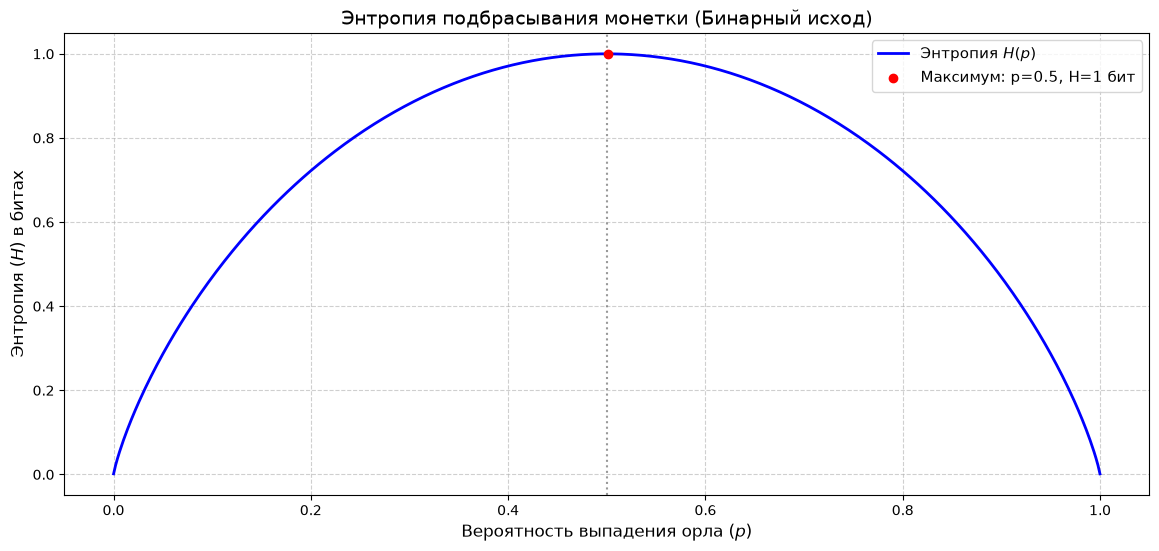

In [3]:
import matplotlib.pyplot as plt

p = np.linspace(0.0001, 0.9999, 500)
H = - (p * np.log2(p) + (1 - p) * np.log2(1 - p))

max_idx = np.argmax(H)
p_max = p[max_idx]
H_max = H[max_idx]

plt.figure(figsize=(14, 6))
plt.plot(p, H, label='Энтропия $H(p)$', color='blue', linewidth=2)
plt.scatter(p_max, H_max, color='red', zorder=5, 
            label=f'Максимум: p={p_max:.1f}, H={H_max:.0f} бит')

plt.title('Энтропия подбрасывания монетки (Бинарный исход)', fontsize=14)
plt.xlabel('Вероятность выпадения орла ($p$)', fontsize=12)
plt.ylabel('Энтропия ($H$) в битах', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.axvline(x=0.5, color='gray', linestyle=':', alpha=0.8)
plt.legend(fontsize=11)
plt.show()

---
2. **Энтропия модели на MNIST.** Высокая энтропия предсказания → больше ошибок?


In [4]:
def entropy(p):
    p = np.asarray(p)
    return -np.sum(p * np.log2(p + 1e-12), axis=1)

def entropy_max(N):
    return np.log2(N)

# Имитируем выходы Softmax для 3 картинок (10 классов)
# Строка 0: Уверенное и правильное предсказание (Низкая энтропия)
# Строка 1: Модель сомневается между 4 и 9 (Высокая энтропия)
# Строка 2: Излишне уверенная ошибка (Низкая энтропия)
N = 10
mock_predictions = np.array([
    [0.91, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01],
    [0.01, 0.01, 0.01, 0.01, 0.45, 0.01, 0.01, 0.01, 0.01, 0.44],
    [0.01, 0.01, 0.01, 0.91, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01]
])

true_labels = np.array([0, 4, 5])

entropy_val = entropy(mock_predictions)
entropy_percent = (entropy_val / entropy_max(N)) * 100

predicted_labels = np.argmax(mock_predictions, axis=1)
is_error = predicted_labels != true_labels

for i in range(len(true_labels)):
    print(f"Объект {i}: Истинный класс: {true_labels[i]}, Предсказанный: {predicted_labels[i]}")
    print(f"  Энтропия предсказания: {entropy_val[i]:.2f} бит")
    print(f"  Энтропия предсказания: {entropy_percent[i]:.2f} %")
    print(f"  Ошибка модели: {is_error[i]}\n")


Объект 0: Истинный класс: 0, Предсказанный: 0
  Энтропия предсказания: 0.72 бит
  Энтропия предсказания: 21.73 %
  Ошибка модели: False

Объект 1: Истинный класс: 4, Предсказанный: 4
  Энтропия предсказания: 1.57 бит
  Энтропия предсказания: 47.29 %
  Ошибка модели: False

Объект 2: Истинный класс: 5, Предсказанный: 3
  Энтропия предсказания: 0.72 бит
  Энтропия предсказания: 21.73 %
  Ошибка модели: True



---
3. **Cross-entropy руками.** Без `torch.nn.functional`. Обучите сеть на CIFAR-10.


In [5]:
import torch # тензоры и нейросети
import torch.nn as nn # готовые слои нейросетей (линейные, сверточные и т.д)
import torch.optim as optim # алгоритмы оптимизации (Adam, SGD и т.д)
import torchvision #датасеты (CIFAR-10), модели и архитектуры
import torchvision.transforms as transforms # предобработка изображений (превращение картинок из датасета в тензоры)


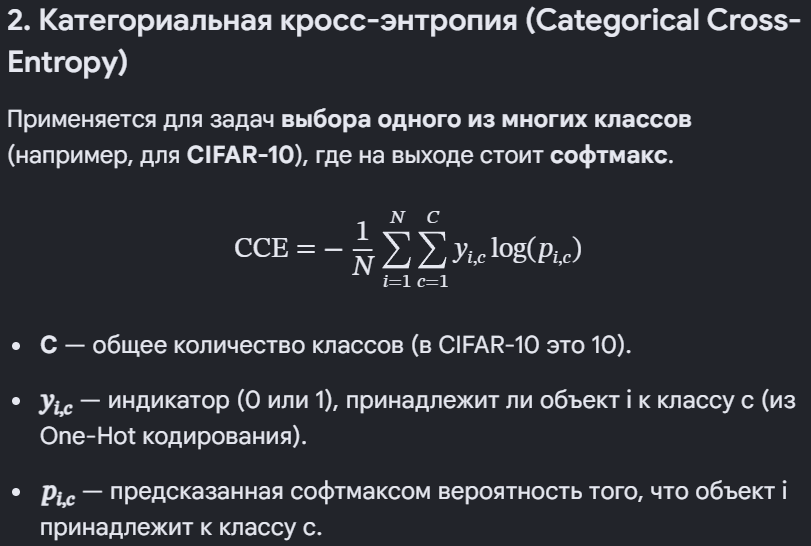

In [6]:
# Реализация функции потерь Categorical Cross-Entropy «руками»
def cross_entropy_manual(logits, targets):
    # (значения, индексы значений)
    # защита от возведения экспоненты в большую степень
    max_logit = torch.max(logits, dim=1, keepdim=True)[0] # берем максимальное значение логита
    exp_logits = torch.exp(logits - max_logit)
    probs = exp_logits / (torch.sum(exp_logits, dim=1, keepdim=True)) # предсказанные вероятности

    batch_size = logits.shape[0]
    true_class_probs = probs[torch.arange(batch_size), targets]

    # Считаем ошибку (минус логарифм) с защитой от log(0)
    loss = - torch.log(true_class_probs + 1e-15)

    # берем среднее, чтобы размер батча не влиял на масштаб loss
    return torch.mean(loss)


In [7]:
# 1. Задаем правила предобработки (трансформации) для картинок
transform = transforms.Compose([
    transforms.ToTensor(),  # Превращает картинку из формата PIL (0-255) в тензор PyTorch (0.0 - 1.0)
    transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))  # Сдвигает значения пикселей в диапазон от -1.0 до 1.0
])

# 2. Скачиваем официальный тренировочный датасет CIFAR-10 (50 000 картинок)
full_trainset = torchvision.datasets.CIFAR10(
    root='./data',        # Папка, куда сохранятся картинки
    train=True,           # Указываем, что это выборка для обучения
    download=True,        # Разрешаем скачать из интернета, если её еще нет на компьютере
    transform=transform   # Применяем наши правила предобработки, созданные выше
)

# 3. Делаем подвыборку (Subset) на 5000 картинок для экономии времени
trainset = torch.utils.data.Subset(full_trainset, range(5000))

# 4. Упаковываем данные в DataLoader для автоматической нарезки на батчи
trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=64,  # Сеть будет смотреть по 64 картинки за один шаг
    shuffle=True    # Перемешиваем данные перед каждой эпохой, чтобы сеть не заучивала порядок
)



In [8]:
# Построение сверточной нейросети (Convolutional Neural Network — CNN)
# Шаг 4: Создание архитектуры нейросети SimpleCNN

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        
        # 1. Блок извлечения признаков (фичей) из картинок
        self.features = nn.Sequential(
            # Вход: 3 канала (RGB), 16 фильтров, размер ядра 3x3. Выход: [64, 16, 32, 32]
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),  # Функция активации (убирает отрицательные значения, добавляя нелинейность)
            nn.MaxPool2d(2, 2),  # Сжимает картинку в 2 раза по высоте и ширине. Выход: [64, 16, 16, 16]
            
            # Второй слой свертки: из 16 фильтров делаем 32. Выход: [64, 32, 16, 16]
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)  # Еще раз сжимаем в 2 раза. Выход: [64, 32, 8, 8]
        )
        
        # 2. Блок классификации (принимает фичи и выдает финальный ответ)
        self.classifier = nn.Sequential(
            nn.Flatten(),  # Вытягивает многомерную матрицу [32, 8, 8] в плоский вектор размера 2048
            nn.Linear(32 * 8 * 8, 128),  # Полносвязный слой: из 2048 признаков делает 128
            nn.ReLU(),
            nn.Linear(128, 10)  # Выходной слой: выдает 10 чисел (логитов) по числу классов CIFAR-10
        )

    def forward(self, x):
        # Описываем путь данных внутри сети: сначала извлекаем фичи, потом классифицируем
        x = self.features(x)
        return self.classifier(x)


In [9]:
# 5. Создаем модель
model = SimpleCNN()

# 6. Выбираем оптимизатор
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 7. Обучаем сеть
num_epochs = 5

for epoch in range(num_epochs):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in trainloader:
        # Обнуляем градиенты от предыдущего шага
        optimizer.zero_grad()

        # Прямой проход:
        # images: [batch_size, 3, 32, 32]
        # logits: [batch_size, 10]
        logits = model(images)

        # Считаем Cross-Entropy (кросс-энтропию) вручную
        loss = cross_entropy_manual(logits, labels)

        # Обратное распространение ошибки
        loss.backward()

        # Обновляем веса сети
        optimizer.step()

        # Суммируем loss (функцию потерь)
        running_loss += loss.item()

        # Находим класс с максимальным логитом
        predicted = torch.argmax(logits, dim=1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    # Средний loss за эпоху
    epoch_loss = running_loss / len(trainloader)

    # Accuracy (точность) в процентах
    epoch_accuracy = 100.0 * correct / total

    print(
        f"Epoch [{epoch + 1}/{num_epochs}], "
        f"Loss: {epoch_loss:.4f}, "
        f"Accuracy: {epoch_accuracy:.2f}%"
    )

Epoch [1/5], Loss: 1.9265, Accuracy: 31.16%
Epoch [2/5], Loss: 1.5830, Accuracy: 43.54%
Epoch [3/5], Loss: 1.4258, Accuracy: 48.28%
Epoch [4/5], Loss: 1.3461, Accuracy: 52.34%
Epoch [5/5], Loss: 1.2403, Accuracy: 55.16%


In [10]:
# 8. Загружаем официальную тестовую выборку CIFAR-10
testset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

testloader = torch.utils.data.DataLoader(
    testset,
    batch_size=64,
    shuffle=False
)

# 9. Оцениваем модель на тестовых данных
model.eval()

test_loss = 0.0
correct = 0
total = 0

# Градиенты при тестировании не нужны
with torch.no_grad():
    for images, labels in testloader:
        # images: [batch_size, 3, 32, 32]
        # logits: [batch_size, 10]
        logits = model(images)

        # Считаем Cross-Entropy (кросс-энтропию) нашей ручной функцией
        loss = cross_entropy_manual(logits, labels)

        test_loss += loss.item()

        # Выбираем класс с максимальным логитом
        predicted = torch.argmax(logits, dim=1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

average_test_loss = test_loss / len(testloader)
test_accuracy = 100.0 * correct / total

print(f"Test Loss: {average_test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Loss: 1.3588
Test Accuracy: 51.19%


Модель обучалась на подвыборке из 5000 изображений CIFAR-10. В течение пяти эпох значение Cross-Entropy (кросс-энтропии) уменьшилось с 1.9648 до 1.2823, а точность на обучающей выборке выросла с 28.92% до 54.96%. На тестовой выборке модель получила точность 50.31%. Разница между train и test accuracy составляет 4.65 процентного пункта, поэтому сильного переобучения не наблюдается. Ручная реализация Cross-Entropy корректно участвует в backpropagation (обратном распространении ошибки), поскольку все операции выполнены средствами PyTorch над тензорами и сохраняют вычислительный граф.

---
Мы обучили свёрточную нейронную сеть классифицировать изображения CIFAR-10. Свёрточные слои извлекают пространственные признаки изображения, например границы и более сложные визуальные структуры. После pooling карты признаков уменьшаются, затем преобразуются в вектор и передаются полносвязным слоям, которые выдают 10 логитов — по одному для каждого класса. Затем вручную вычисляется Cross-Entropy, которая показывает, насколько сеть ошиблась. С помощью backpropagation PyTorch вычисляет градиенты функции потерь, а оптимизатор Adam обновляет веса сети, чтобы уменьшить ошибку.

---
---
4. **KL не симметрична.** `p = N(0, 1)`, `q = N(1, 2)`. Посчитайте `KL(p || q)` и `KL(q || p)`.

## KL-divergence (дивергенция Кульбака–Лейблера)

KL-divergence показывает, насколько одно вероятностное распределение отличается от другого.

Обозначается:

$$
D_{KL}(p \| q)
$$

Для непрерывных распределений:

$$
D_{KL}(p \| q)
=
\int p(x)\log\frac{p(x)}{q(x)}dx
$$

Важно: KL-divergence не является обычным расстоянием, потому что в общем случае

$$
D_{KL}(p \| q)
\neq
D_{KL}(q \| p)
$$

То есть KL-divergence несимметрична.

---

## Почему KL несимметрична

В выражении

$$
D_{KL}(p \| q)
$$

усреднение выполняется по распределению $p(x)$.

А в выражении

$$
D_{KL}(q \| p)
$$

усреднение уже выполняется по $q(x)$.

Поэтому перестановка распределений местами меняет результат.

---

## KL для нормальных распределений

Пусть

$$
p = \mathcal{N}(\mu_p, \sigma_p^2)
$$

$$
q = \mathcal{N}(\mu_q, \sigma_q^2)
$$

Тогда

$$
D_{KL}(p \| q)
=
\log\frac{\sigma_q}{\sigma_p}
+
\frac{
\sigma_p^2 + (\mu_p - \mu_q)^2
}{
2\sigma_q^2
}
-
\frac{1}{2}
$$

Эквивалентная форма через дисперсии:

$$
D_{KL}(p \| q)
=
\frac{1}{2}
\left(
\log\frac{\sigma_q^2}{\sigma_p^2}
+
\frac{
\sigma_p^2 + (\mu_p - \mu_q)^2
}{
\sigma_q^2
}
-1
\right)
$$


In [11]:
import math

def kl_divergence(mu1, sigma1_sq, mu2, sigma2_sq):
    return (
        math.log(math.sqrt(sigma2_sq) / math.sqrt(sigma1_sq)) 
        + (sigma1_sq + (mu1 - mu2)**2) / (2 * sigma2_sq) 
        - 0.5
    )


kl_pq = kl_divergence(0, 1, 1, 2)
kl_qp = kl_divergence(1, 2, 0, 1)
print(f"KL(p || q) = {kl_pq:.4f}")
print(f"KL(q || p) = {kl_qp:.4f}\n")

KL(p || q) = 0.3466
KL(q || p) = 0.6534



---
5. **Mode-seeking vs mass-covering.** Бимодальное `p`, гаусс `q`. `KL(p || q)` vs `KL(q || p)` — где `q` ляжет?

# Mode-seeking vs Mass-covering

Пусть истинное распределение $p(x)$ является бимодальным, то есть имеет два пика:

$$
p(x)
=
\frac{1}{2}\mathcal{N}(-2, 1)
+
\frac{1}{2}\mathcal{N}(2, 1)
$$

А распределение $q(x)$ будем приближать одним гауссовским распределением:

$$
q(x)
=
\mathcal{N}(\mu_q, \sigma_q^2)
$$

Так как $q(x)$ имеет только один пик, оно не может идеально повторить бимодальное распределение $p(x)$.

Поэтому результат зависит от того, в каком направлении считается KL-divergence (дивергенция Кульбака–Лейблера).

---

## Forward KL

Рассмотрим:

$$
D_{KL}(p \| q)
=
\int
p(x)
\log
\frac{p(x)}{q(x)}
dx
$$

Здесь интеграл взвешивается значениями $p(x)$.

Если в некоторой области:

$$
p(x) > 0
$$

а

$$
q(x) \approx 0
$$

то отношение

$$
\frac{p(x)}{q(x)}
$$

становится большим, и KL сильно увеличивается.

Поэтому $q(x)$ старается не пропустить области, где $p(x)$ имеет большую вероятность.

Для бимодального $p(x)$ один гаусс $q(x)$ обычно становится широким и располагается между двумя модами, чтобы покрыть обе.

Такое поведение называется:

$$
\boxed{\text{mass-covering}}
$$

то есть покрытие вероятностной массы.

---

## Reverse KL

Теперь рассмотрим:

$$
D_{KL}(q \| p)
=
\int
q(x)
\log
\frac{q(x)}{p(x)}
dx
$$

Здесь интеграл уже взвешивается значениями $q(x)$.

Если $q(x)$ положительно в области, где

$$
p(x) \approx 0
$$

то отношение

$$
\frac{q(x)}{p(x)}
$$

становится большим, и возникает сильный штраф.

Поэтому $q(x)$ старается не размещать вероятность там, где $p(x)$ мало.

Для бимодального $p(x)$ это приводит к тому, что один гаусс $q(x)$ обычно выбирает одну из мод и концентрируется около неё.

Такое поведение называется:

$$
\boxed{\text{mode-seeking}}
$$

то есть поиск моды.

---

## Главное различие

Для

$$
D_{KL}(p \| q)
$$

важно:

$$
\boxed{
\text{не пропустить области, где } p(x) \text{ большое}
}
$$

Поэтому получается mass-covering.

Для

$$
D_{KL}(q \| p)
$$

важно:

$$
\boxed{
\text{не размещать вероятность там, где } p(x) \text{ маленькое}
}
$$

Поэтому получается mode-seeking.

---

## Вывод

Для бимодального $p(x)$ и одномодального гауссовского $q(x)$:

$$
\boxed{
KL(p \| q)
\rightarrow
q \text{ покрывает обе моды}
}
$$

$$
\boxed{
KL(q \| p)
\rightarrow
q \text{ выбирает одну из мод}
}
$$

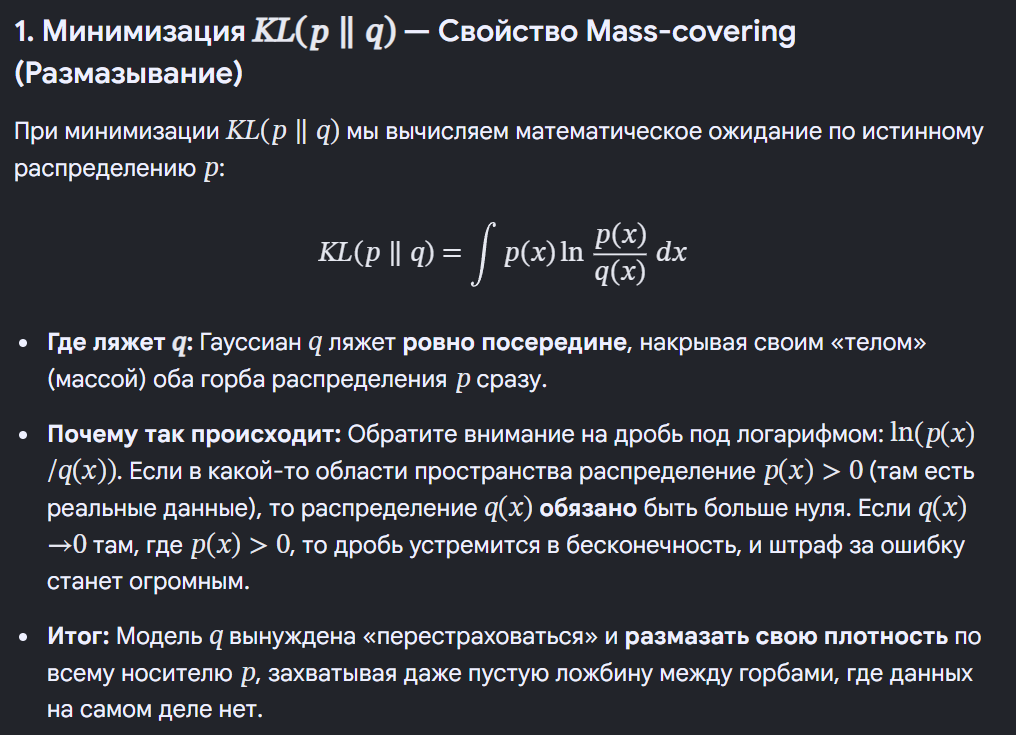
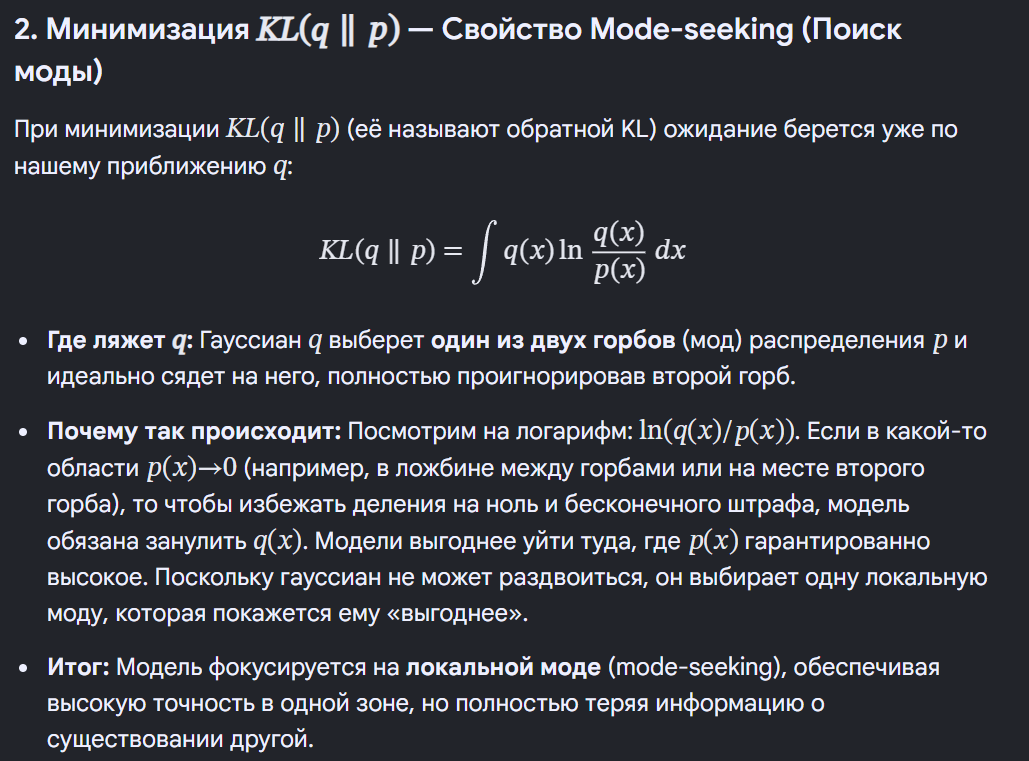
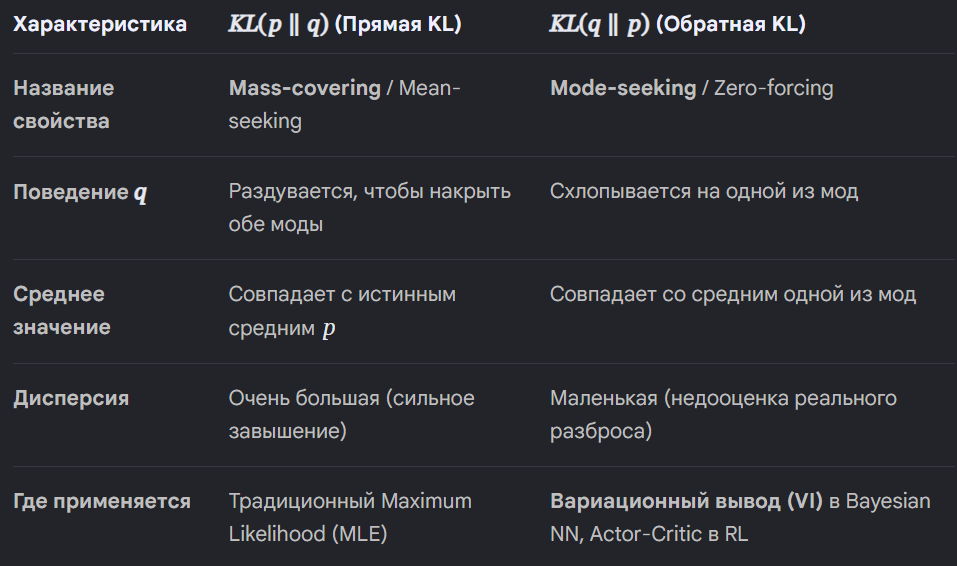

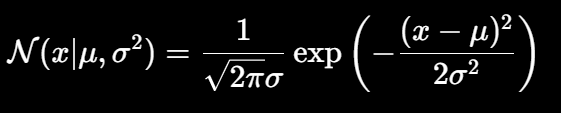

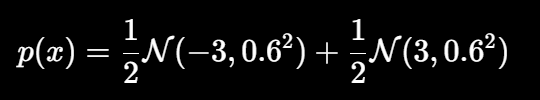

In [12]:
import math
import numpy as np


# функция плотности Гауссина (гауссовское распределение)
def normal_pdf(x, mu, sigma):
    return torch.exp(
        -0.5 * ((x - mu) / sigma) ** 2
    ) / (sigma * math.sqrt(2 * math.pi))


# def kl_divergence(p_values, q_values, x):
#     eps = 1e-12

#     p_safe = p_values + eps
#     q_safe = q_values + eps

#     integrand = p_safe * (np.log(p_safe / q_safe))
#     return np.trapezoid(integrand, x)


def kl_divergence(f, s):
    eps = 1e-12

    f_safe = f.clamp_min(eps)
    s_safe = s.clamp_min(eps)

    values = f_safe * torch.log(f_safe / s_safe)

    # приближенный подсчет мтеодом трапеций
    return torch.trapezoid(values, x)


x = torch.linspace(-8.0, 8.0, 3000)

# биноминальное распределение
p = 0.5 * normal_pdf(x, -3.0, 0.6) + 0.5 * normal_pdf(x, 3.0, 0.6)



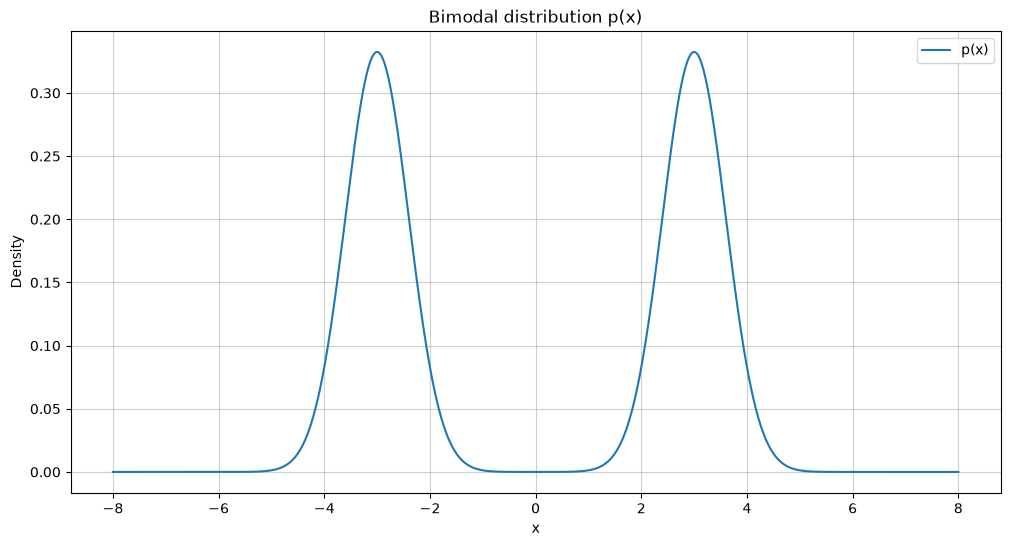

In [13]:
plt.figure(figsize=(12, 6))
plt.plot(x, p, label="p(x)")
plt.xlabel("x")
plt.ylabel("Density")
plt.title("Bimodal distribution p(x)")
plt.legend()
plt.grid(alpha=0.6)
plt.show()

In [14]:
# Обучаем q для KL(p∥q)
mu_forward = torch.tensor(0.0, requires_grad=True)
log_sigma_forward = torch.tensor(0.0, requires_grad=True) 

# Создаем оптимизатор
optimizer_forward = torch.optim.Adam([mu_forward, log_sigma_forward], lr=0.03)

# Обучение Forward KL
for step in range(1500):
    # обнуляем градиенты предыдущей итерации, чтобы не накапливать градиенты
    optimizer_forward.zero_grad()

    sigma_forward = torch.exp(log_sigma_forward)
    q_forward = normal_pdf(x, mu=mu_forward, sigma=sigma_forward)
    loss_forward = kl_divergence(p, q_forward)

    # вычисление градиентов по mu и log(sigma)
    loss_forward.backward()

    # Adam обновляет параметры mu и log(sigma)
    optimizer_forward.step()

sigma_forward = torch.exp(log_sigma_forward)
print(
    f"Forward KL: "
    f"mu = {mu_forward.item():.3f}, " 
    f"sigma = {sigma_forward.item():.3f}"
)

Forward KL: mu = -0.000, sigma = 3.059


In [15]:
mu_reverse = torch.tensor(-2.0, requires_grad=True) # уйдем к левой моде из-за -2
log_sigma_reverse = torch.tensor(0.0, requires_grad=True)

optimizer_reverse = torch.optim.Adam([mu_reverse, log_sigma_reverse], lr=0.03)

for step in range(1500):
    optimizer_reverse.zero_grad()

    sigma_reverse = torch.exp(log_sigma_reverse)
    q_reverse = normal_pdf(x, mu=mu_reverse, sigma=sigma_reverse)
    loss_reverse = kl_divergence(q_reverse, p)

    loss_reverse.backward()
    optimizer_reverse.step()

sigma_reverse = torch.exp(log_sigma_reverse)
print(
    f"Reverse KL: "
    f"mu = {mu_reverse.item():.3f}, " 
    f"sigma = {sigma_reverse.item():.3f}"
)

Reverse KL: mu = -3.000, sigma = 0.600


In [16]:
with torch.no_grad():
    q_forward_final = normal_pdf(x, mu=mu_forward, sigma=sigma_forward)

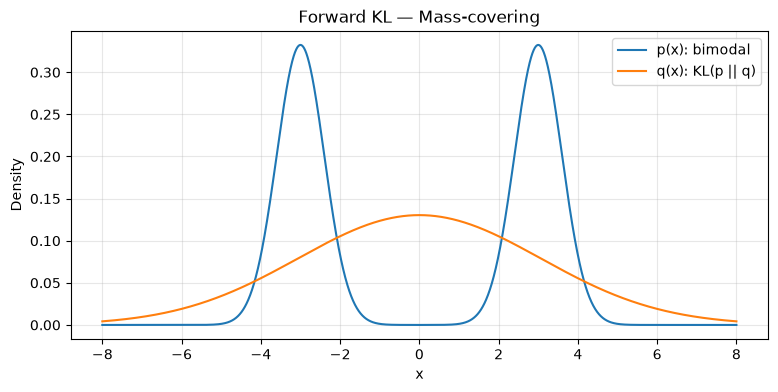

In [17]:
plt.figure(figsize=(9, 4))

plt.plot(x, p, label="p(x): bimodal")
plt.plot(x, q_forward_final, label="q(x): KL(p || q)")

plt.xlabel("x")
plt.ylabel("Density")
plt.title("Forward KL — Mass-covering")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [18]:
with torch.no_grad():
    q_reverse_final = normal_pdf(x, mu_reverse, sigma_reverse)

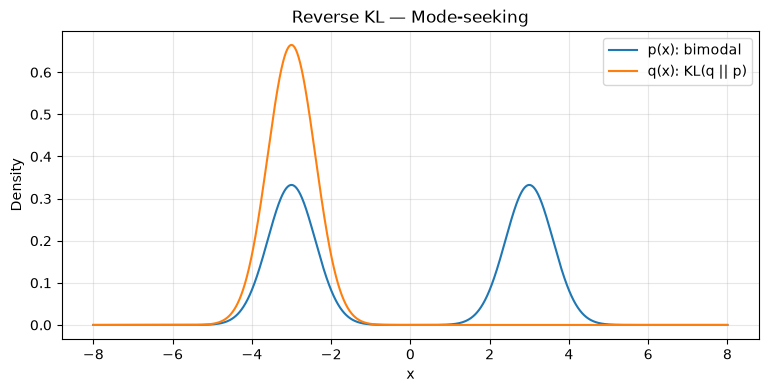

In [19]:
plt.figure(figsize=(9, 4))

plt.plot(x, p, label="p(x): bimodal")
plt.plot(x, q_reverse_final, label="q(x): KL(q || p)")

plt.xlabel("x")
plt.ylabel("Density")
plt.title("Reverse KL — Mode-seeking")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## Вывод

При минимизации

$$
KL(p \| q)
$$

гауссовское распределение $q(x)$ становится широким и располагается между двумя модами распределения $p(x)$, стараясь покрыть обе области высокой вероятности. Это соответствует поведению **mass-covering**.

При минимизации

$$
KL(q \| p)
$$

распределение $q(x)$ концентрируется около одной из мод распределения $p(x)$ и практически игнорирует вторую. Это соответствует поведению **mode-seeking**.

Таким образом, направление KL-divergence существенно влияет на результат приближения:

$$
KL(p \| q)
\rightarrow
\text{mass-covering}
$$

$$
KL(q \| p)
\rightarrow
\text{mode-seeking}
$$

---
---
6. **MI для feature selection.** На Wine: MI каждой фичи с таргетом. Сравните с корреляцией.

Mutual Information измеряет, сколько информации признак содержит о целевом классе. В отличие от корреляции, она способна обнаруживать не только линейные, но и нелинейные зависимости. Поэтому MI подходит для feature selection в задачах классификации, где таргет дискретный. Корреляция с числовыми кодами классов может использоваться для сравнения, но её интерпретация ограничена и зависит от кодировки классов.

In [28]:
import pandas as pd
from sklearn.datasets import load_wine
from sklearn.feature_selection import mutual_info_classif


wine = load_wine(as_frame=True)

X = wine.data
y = wine.target

In [29]:
X.shape

(178, 13)

In [30]:
y.shape

(178,)

In [36]:
mi_scores = mutual_info_classif(X, y, random_state=42)
print(mi_scores)

[0.47431199 0.28238354 0.07920099 0.23780602 0.2133521  0.40159875
 0.66760242 0.12097138 0.30540594 0.54827364 0.46641156 0.51615784
 0.5773907 ]


In [38]:
corr_scores = X.corrwith(y)
print(corr_scores)

alcohol                        -0.328222
malic_acid                      0.437776
ash                            -0.049643
alcalinity_of_ash               0.517859
magnesium                      -0.209179
total_phenols                  -0.719163
flavanoids                     -0.847498
nonflavanoid_phenols            0.489109
proanthocyanins                -0.499130
color_intensity                 0.265668
hue                            -0.617369
od280/od315_of_diluted_wines   -0.788230
proline                        -0.633717
dtype: float64


In [39]:
results = pd.DataFrame({
    "Feature": X.columns,
    "MI": mi_scores,
    "Correlation": corr_scores.values
})

results["Abs correlation"] = results["Correlation"].abs()
results = results.sort_values("MI", ascending=False).reset_index(drop=True)

results

,Feature,MI,Correlation,Abs correlation
0,flavanoids,0.667602,-0.847498,0.847498
1,proline,0.577391,-0.633717,0.633717
2,color_intensity,0.548274,0.265668,0.265668
3,od280/od315_of_diluted_wines,0.516158,-0.788230,0.788230
4,alcohol,0.474312,-0.328222,0.328222
5,hue,0.466412,-0.617369,0.617369
6,total_phenols,0.401599,-0.719163,0.719163
7,proanthocyanins,0.305406,-0.499130,0.499130
8,malic_acid,0.282384,0.437776,0.437776
9,alcalinity_of_ash,0.237806,0.517859,0.517859


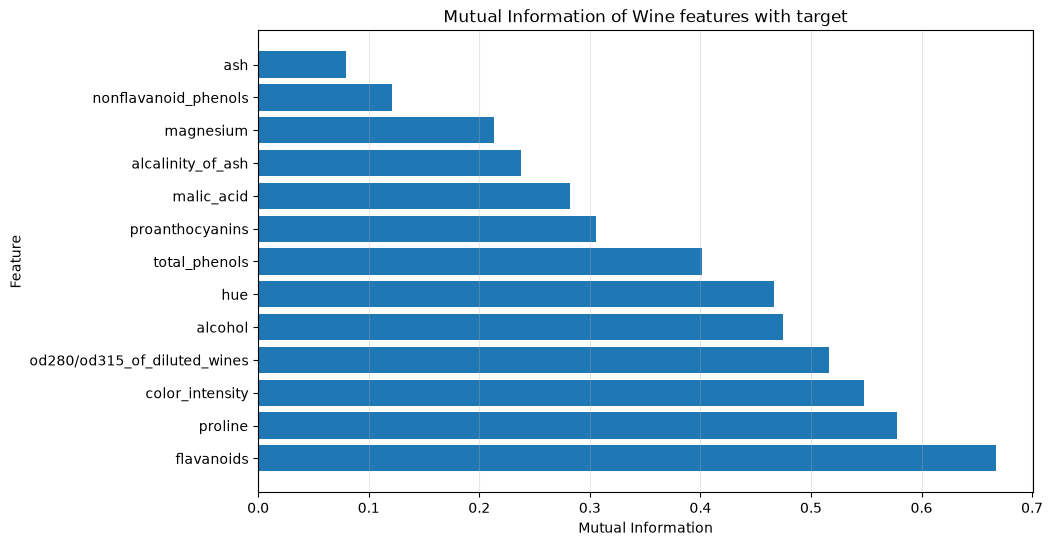

In [41]:
plt.figure(figsize=(10, 6))
plt.barh(results["Feature"], results["MI"])
# plt.gca().invert_yaxis()

plt.xlabel("Mutual Information")
plt.ylabel("Feature")
plt.title("Mutual Information of Wine features with target")
plt.grid(axis="x", alpha=0.3)
plt.show()

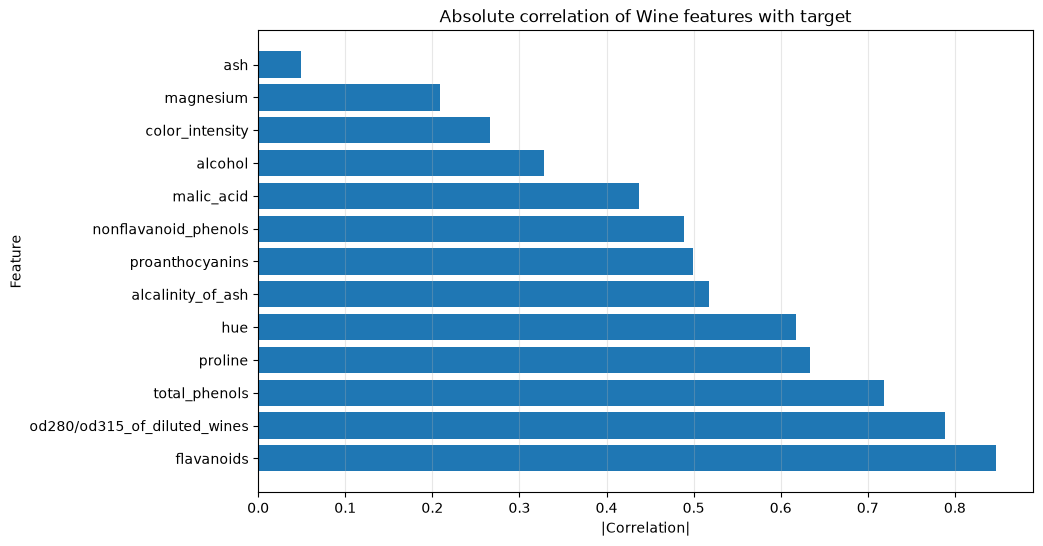

In [45]:
corr_results = results.sort_values("Abs correlation", ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(corr_results["Feature"], corr_results["Abs correlation"])
# plt.gca().invert_yaxis()

plt.xlabel("|Correlation|")
plt.ylabel("Feature")
plt.title("Absolute correlation of Wine features with target")
plt.grid(axis="x", alpha=0.3)
plt.show()

## Вывод

Mutual Information и корреляция по-разному оценивают связь признаков с таргетом.

Наиболее информативным признаком по Mutual Information оказался `flavanoids`:

$$
MI \approx 0.668
$$

При этом он также имеет высокую по модулю корреляцию:

$$
|\rho| \approx 0.847
$$

Это означает, что признак хорошо связан с классом и зависимость во многом выраженная.

Интересный пример — `color_intensity`:

$$
MI \approx 0.548
$$

но

$$
|\rho| \approx 0.266
$$

То есть Mutual Information обнаруживает сильную зависимость, которую обычная линейная корреляция почти не отражает. Это показывает преимущество MI: она способна учитывать не только линейные, но и более сложные зависимости.

В целом результаты показывают, что для feature selection в задаче классификации Mutual Information является более подходящей мерой, чем корреляция с числовыми кодами классов.

---
7. **KL в VAE.** Найдите `KL(q(z|x) || N(0, I))` в коде. Что регуляризует?

# VAE: автоэнкодер, латентное пространство, репараметризация и KL-дивергенция

## 1. Что такое автоэнкодер

`Autoencoder` (автоэнкодер) — это нейросеть, которая учится восстановить свой же вход.

Общая схема:

$$
x \rightarrow \text{Encoder} \rightarrow z \rightarrow \text{Decoder} \rightarrow \hat{x}
$$

где:

- $x$ — исходный объект;
- `Encoder` (энкодер) — преобразует вход в скрытое представление;
- $z$ — латентный вектор, то есть сжатое представление объекта;
- `Decoder` (декодер) — восстанавливает объект по $z$;
- $\hat{x}$ — восстановленный объект.

Например, если на входе изображение размером $28 \times 28$, то оно содержит:

$$
28 \cdot 28 = 784
$$

числа. Энкодер может сжать его до латентного вектора длины 32:

$$
784 \rightarrow 32
$$

а декодер восстановить обратно:

$$
32 \rightarrow 784
$$

То есть автоэнкодер учится хранить важную информацию об объекте в более компактном виде.

---

## 2. Что такое latent space

`Latent space` (латентное пространство) — это пространство скрытых признаков, в котором живут векторы $z$.

Например:

$$
z = [0.4,\,-1.2,\,0.7,\,2.1]
$$

Это уже не пиксели и не исходные признаки. Это внутреннее представление, которое сеть сама научилась использовать.

Если латентная размерность равна 2, то каждый объект можно представить как точку на плоскости:

$$
z = [z_1, z_2]
$$

Например:

$$
z_1 = [-2, 1], \qquad z_2 = [0.5, -1]
$$

---

## 3. Как обучается обычный автоэнкодер

Энкодер строит:

$$
z = Encoder(x)
$$

декодер строит:

$$
\hat{x} = Decoder(z)
$$

После этого сравниваем исходный объект и восстановленный:

$$
x \quad \text{и} \quad \hat{x}
$$

Например, можно использовать `MSE` (`Mean Squared Error` — среднеквадратичную ошибку):

$$
L_{\text{rec}}
=
\frac{1}{N}\sum_i (x_i-\hat{x}_i)^2
$$

Чем ближе $\hat{x}$ к $x$, тем меньше ошибка.

---

## 4. В чём проблема обычного автоэнкодера

Обычный автоэнкодер не обязан делать латентное пространство аккуратным.

Он может кодировать разные объекты в очень далёкие и произвольные точки:

$$
x_1 \rightarrow z_1=[-20,50]
$$

$$
x_2 \rightarrow z_2=[100,-80]
$$

$$
x_3 \rightarrow z_3=[7,200]
$$

Для восстановления это может работать нормально, потому что декодер запоминает, как работать с такими точками.

Но если взять случайный новый $z$, например:

$$
z=[0,0]
$$

то декодер может не знать, что с ним делать, потому что во время обучения таких точек рядом не было.

То есть обычный автоэнкодер хорошо умеет:

$$
x \rightarrow z \rightarrow \hat{x}
$$

но не гарантирует:

$$
\text{случайный } z \rightarrow \text{осмысленный новый объект}
$$

---

## 5. Что меняется в VAE

`VAE` (`Variational Autoencoder` — вариационный автоэнкодер) делает иначе.

Обычный автоэнкодер выдаёт одну фиксированную точку:

$$
x \rightarrow z
$$

А VAE выдаёт параметры распределения:

$$
x \rightarrow \mu, \sigma^2
$$

То есть энкодер задаёт распределение:

$$
q(z|x)
=
\mathcal N(\mu(x), \operatorname{diag}(\sigma^2(x)))
$$

Здесь:

- $\mu$ — вектор средних;
- $\sigma^2$ — вектор дисперсий;
- $q(z|x)$ — распределение латентного кода для конкретного входа $x$.

---

## 6. Что такое $z$ в VAE

Важно различать:

$$
q(z|x)
$$

— это распределение,

а:

$$
z
$$

— это конкретный латентный вектор, случайно выбранный из этого распределения.

Например энкодер выдал:

$$
\mu=[1.0,-0.5]
$$

$$
\sigma=[0.2,0.3]
$$

Это задаёт двумерное распределение.

Из него можно получить:

$$
z=[0.92,-0.61]
$$

или при другой выборке:

$$
z=[1.08,-0.44]
$$

То есть один и тот же вход $x$ может давать немного разные $z$.

Если используется батч, то $z$ технически является тензором формы:

$$
[\text{batch size}, \text{latent dim}]
$$

Например:

$$
[64,20]
$$

Это означает 64 объекта, и у каждого свой латентный вектор длины 20.

---

## 7. Зачем VAE использует распределение, а не одну точку

Это делает латентное пространство более гладким.

В обычном автоэнкодере один объект может соответствовать одной жёсткой точке.

В VAE объект соответствует некоторой области:

$$
q(z|x)
$$

Поэтому соседние точки латентного пространства чаще соответствуют похожим объектам.

Это полезно для генерации новых данных и плавных переходов между объектами.

---

## 8. Как получить конкретный $z$

Можно было бы написать:

$$
z \sim \mathcal N(\mu,\sigma^2)
$$

то есть напрямую взять случайную выборку из распределения.

Но для обучения через `backpropagation` (обратное распространение ошибки) это неудобно.

Причина в том, что операция случайной выборки не является обычной детерминированной функцией вида:

$$
z=f(\mu,\sigma)
$$

При одинаковых $\mu$ и $\sigma$ каждый раз можно получить разные значения $z$.

Например при:

$$
\mu=0,\qquad \sigma=1
$$

можно получить:

$$
z=0.2
$$

или:

$$
z=-1.3
$$

или:

$$
z=2.1
$$

Чтобы обучать энкодер, нам нужны градиенты:

$$
\frac{\partial L}{\partial \mu}
$$

и:

$$
\frac{\partial L}{\partial \sigma}
$$

Поэтому используют `reparameterization trick` (трюк репараметризации).

---

## 9. Reparameterization trick

Вместо прямой случайной выборки пишут:

$$
\varepsilon \sim \mathcal N(0,I)
$$

и:

$$
z=\mu+\sigma\odot\varepsilon
$$

Здесь:

- $\varepsilon$ — случайный шум;
- $\mu$ — среднее;
- $\sigma$ — стандартное отклонение;
- $\odot$ — поэлементное умножение.

Теперь случайность находится только в $\varepsilon$, а $z$ становится обычной функцией от $\mu$ и $\sigma$.

Для одного измерения:

$$
z=\mu+\sigma\varepsilon
$$

Тогда:

$$
\frac{\partial z}{\partial \mu}=1
$$

и:

$$
\frac{\partial z}{\partial \sigma}=\varepsilon
$$

Поэтому по правилу цепочки:

$$
\frac{\partial L}{\partial \mu}
=
\frac{\partial L}{\partial z}
\frac{\partial z}{\partial \mu}
$$

и:

$$
\frac{\partial L}{\partial \sigma}
=
\frac{\partial L}{\partial z}
\frac{\partial z}{\partial \sigma}
$$

То есть градиенты могут пройти через $z$ обратно к энкодеру.

Пример: пусть

$$
\mu=2,\qquad \sigma=3,\qquad \varepsilon=0.5
$$

Тогда:

$$
z=2+3\cdot0.5=3.5
$$

Если:

$$
L=z^2
$$

то:

$$
\frac{\partial L}{\partial z}=2z=7
$$

Следовательно:

$$
\frac{\partial L}{\partial \mu}=7
$$

$$
\frac{\partial L}{\partial \sigma}=7\cdot0.5=3.5
$$

И эти градиенты можно использовать для обновления параметров энкодера.

---

## 10. Что такое $I$ в $\mathcal N(0,I)$

В VAE обычно задают prior:

$$
p(z)=\mathcal N(0,I)
$$

$I$ — это `identity matrix` (единичная матрица).

Например в трёх измерениях:

$$
I=
\begin{bmatrix}
1 & 0 & 0 \\
0 & 1 & 0 \\
0 & 0 & 1
\end{bmatrix}
$$

Поэтому:

$$
\mathcal N(0,I)
$$

означает многомерное нормальное распределение, в котором:

$$
\mu=0
$$

$$
Var(z_j)=1
$$

и разные координаты не коррелируют:

$$
Cov(z_i,z_j)=0,\qquad i\neq j
$$

То есть каждая латентная координата имеет нулевое среднее и единичную дисперсию.

---

## 11. Зачем нужен prior

Если просто разрешить энкодеру выбирать любые $\mu$ и $\sigma$, латентное пространство снова может стать хаотичным.

Например:

$$
q(z|x_1)=\mathcal N(-100,0.01)
$$

$$
q(z|x_2)=\mathcal N(200,0.01)
$$

Поэтому задаётся простое эталонное распределение:

$$
p(z)=\mathcal N(0,I)
$$

и требуется, чтобы распределения энкодера:

$$
q(z|x)
$$

не слишком сильно от него отличались.

---

## 12. Где появляется KL-дивергенция

Для этого в функцию потерь добавляют:

$$
D_{KL}\left(q(z|x)\|\mathcal N(0,I)\right)
$$

KL-дивергенция измеряет, насколько распределение энкодера отличается от стандартного нормального распределения.

Для диагонального нормального распределения:

$$
q(z|x)=\mathcal N(\mu,\operatorname{diag}(\sigma^2))
$$

получаем:

$$
D_{KL}(q\|p)
=
\frac{1}{2}\sum_j
\left(
\mu_j^2+\sigma_j^2-\log\sigma_j^2-1
\right)
$$

---

## 13. Что именно регуляризует KL

KL регуляризует латентное пространство.

Она штрафует энкодер, если его распределение слишком далеко от:

$$
\mathcal N(0,I)
$$

Из формулы видно, что член:

$$
\mu_j^2
$$

штрафует большие значения среднего, поэтому:

$$
\mu_j \rightarrow 0
$$

А часть:

$$
\sigma_j^2-\log\sigma_j^2-1
$$

минимальна при:

$$
\sigma_j^2=1
$$

Поэтому KL стремится к:

$$
\mu \rightarrow 0,\qquad \sigma^2 \rightarrow 1
$$

То есть:

$$
q(z|x)\approx\mathcal N(0,I)
$$

---

## 14. Почему все объекты тогда не становятся одинаковыми

Потому что в VAE есть две части функции потерь.

Первая:

$$
L_{\text{reconstruction}}
$$

заставляет сохранять информацию об объекте и хорошо восстанавливать вход.

Вторая:

$$
L_{KL}
$$

не даёт латентным распределениям разлетаться произвольно.

Итог:

$$
L=L_{\text{reconstruction}}+L_{KL}
$$

`Reconstruction loss` говорит:

> хорошо различай объекты и восстанавливай их.

KL говорит:

> при этом держи латентное пространство близким к $\mathcal N(0,I)$.

VAE ищет компромисс между этими двумя требованиями.

---

## 15. Почему VAE может генерировать новые объекты

После обучения можно взять случайный латентный вектор:

$$
z\sim\mathcal N(0,I)
$$

и подать его прямо в декодер:

$$
z \rightarrow Decoder(z)
$$

Поскольку во время обучения KL заставляла латентные распределения быть близкими к $\mathcal N(0,I)$, декодер уже умеет работать с точками из этой области.

Поэтому VAE может не только восстанавливать входы, но и генерировать новые объекты.

---

## 16. Главная схема VAE

Полный путь одного объекта:

$$
x
\rightarrow
Encoder
\rightarrow
(\mu,\log\sigma^2)
\rightarrow
z
\rightarrow
Decoder
\rightarrow
\hat{x}
$$

где:

$$
\sigma=\exp\left(\frac{1}{2}\log\sigma^2\right)
$$

$$
\varepsilon\sim\mathcal N(0,I)
$$

$$
z=\mu+\sigma\odot\varepsilon
$$

Функция потерь:

$$
L=L_{\text{reconstruction}}+
D_{KL}\left(q(z|x)\|\mathcal N(0,I)\right)
$$

Главная идея:

$$
\boxed{
\text{Reconstruction loss сохраняет информацию об объекте}
}
$$

$$
\boxed{
\text{KL регуляризует структуру latent space}
}
$$

Благодаря этому VAE одновременно умеет восстанавливать данные и использовать латентное пространство для генерации новых объектов.

In [ ]:
recon_loss = ((x_hat - x) ** 2).mean()
kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())

loss = recon_loss + kl_loss

Здесь:

mu — вектор средних $\mu$ для латентного распределения;

logvar — $\log\sigma^2$;

mu.pow(2) — $\mu^2$;

logvar.exp() — $\sigma^2$, потому что $e^{\log\sigma^2}=\sigma^2$;

torch.sum(...) — суммирование по латентным координатам.

---
---
8. **Энтропия как уверенность.** Reliability diagram: энтропия предсказания vs точность.

In [60]:
all_entropies = []
all_correct = []

#Переводим модель в режим тестирования
model.eval()

with torch.no_grad():
    for images, labels in testloader:

        # получаем предсказания модели
        logits = model(images)

        # softmax (логиты -> вероятность)
        exp_logits = torch.exp(logits - logits.max(dim=1, keepdim=True).values)
        probs = exp_logits / exp_logits.sum(dim=1, keepdim=True)

        # энтропия для каждой картинки
        entropy = -(probs * torch.log(probs + 1e-12)).sum(dim=1)

        predictions = torch.argmax(probs, dim=1)
        correct = (predictions == labels).float()

        all_entropies.append(entropy)
        all_correct.append(correct)

In [61]:
all_entropies = torch.cat(all_entropies)
all_correct = torch.cat(all_correct)

print(all_entropies.shape)
print(all_correct.shape)

torch.Size([10000])
torch.Size([10000])


In [49]:
num_bins = 10
bin_edges = torch.linspace(all_entropies.min(), all_entropies.max(), num_bins + 1)

bin_entropy = []
bin_accuracy = []

In [62]:
for i in range(num_bins):
    mask = (all_entropies >= bin_edges[i]) & (all_entropies < bin_edges[i + 1])

    if mask.sum() > 0:
        bin_entropy.append(all_entropies[mask].mean().item())
        bin_accuracy.append(all_correct[mask].mean().item())

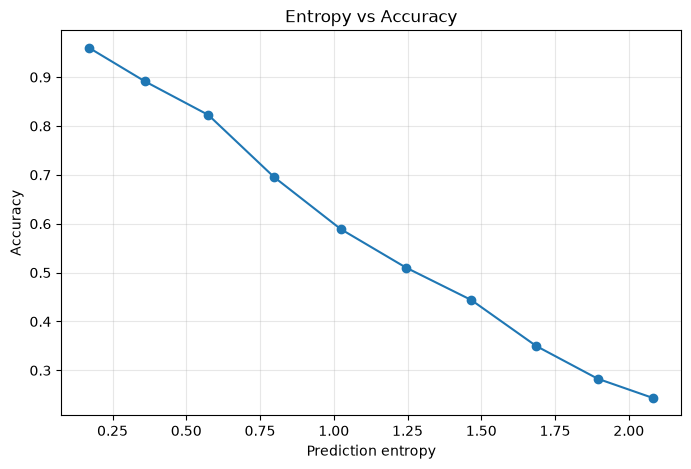

In [54]:
plt.figure(figsize=(8, 5))
plt.plot(bin_entropy, bin_accuracy, marker="o")

plt.xlabel("Prediction entropy")
plt.ylabel("Accuracy")
plt.title("Entropy vs Accuracy")
plt.grid(alpha=0.3)
plt.show()

In [56]:
print(f"Min entropy: {all_entropies.min().item():.4f}")
print(f"Max entropy: {all_entropies.max().item():.4f}")
print(f"Theoretical max для CIFAR: {math.log(10):.4f}")

Min entropy: 0.0139
Max entropy: 2.2466
Theoretical max для CIFAR: 2.3026


# Итог по теме: Entropy, Cross-Entropy и KL-divergence

## 1. Энтропия дискретного распределения

Энтропия измеряет неопределённость случайной величины.

Для дискретного распределения:

$$
H(p) = -\sum_i p_i \log p_i
$$

где $p_i$ — вероятность $i$-го исхода.

Если распределение почти полностью сосредоточено на одном исходе, энтропия маленькая. Если вероятности распределены примерно равномерно, энтропия большая.

Например:

$$
p=[1,0,0]
$$

даёт:

$$
H(p)=0
$$

то есть полной неопределённости нет.

А для:

$$
p=\left[\frac13,\frac13,\frac13\right]
$$

энтропия максимальна:

$$
H(p)=\log 3
$$

---

## 2. Cross-Entropy и MLE в классификации

В задаче классификации модель выдаёт вероятности классов:

$$
q(y|x)
$$

Если правильный класс имеет индекс $y$, то Cross-Entropy для одного объекта:

$$
L=-\log q(y|x)
$$

Для всей выборки:

$$
L=
-\sum_{i=1}^{N}
\log q(y_i|x_i)
$$

Минимизация Cross-Entropy эквивалентна максимизации правдоподобия правильных классов.

Maximum Likelihood Estimation (метод максимального правдоподобия) максимизирует:

$$
\prod_{i=1}^{N} q(y_i|x_i)
$$

После логарифмирования:

$$
\log
\prod_{i=1}^{N} q(y_i|x_i)
=
\sum_{i=1}^{N}\log q(y_i|x_i)
$$

Максимизировать это выражение — то же самое, что минимизировать:

$$
-\sum_{i=1}^{N}\log q(y_i|x_i)
$$

то есть Cross-Entropy.

Поэтому:

$$
\boxed{
\text{минимизация Cross-Entropy}
\equiv
\text{Maximum Likelihood}
}
$$

---

## 3. Асимметрия KL-divergence

KL-divergence определяется как:

$$
D_{KL}(p\|q)
=
\sum_x p(x)\log\frac{p(x)}{q(x)}
$$

или для непрерывных распределений:

$$
D_{KL}(p\|q)
=
\int p(x)\log\frac{p(x)}{q(x)}dx
$$

В общем случае:

$$
D_{KL}(p\|q)
\neq
D_{KL}(q\|p)
$$

Причина в том, что в первом случае усреднение выполняется по $p(x)$, а во втором — по $q(x)$.

Это приводит к разному поведению:

$$
KL(p\|q)
\rightarrow
\text{mass-covering}
$$

то есть распределение $q$ старается покрыть все области, где $p$ имеет существенную вероятность.

А:

$$
KL(q\|p)
\rightarrow
\text{mode-seeking}
$$

то есть $q$ старается находиться в области высокой плотности $p$ и может игнорировать некоторые другие моды.

---

## 4. KL в knowledge distillation

`Knowledge distillation` (дистилляция знаний) — это обучение маленькой модели `student` (ученик) повторять поведение большой модели `teacher` (учитель).

Teacher задаёт распределение:

$$
p_T(y|x)
$$

Student задаёт:

$$
p_S(y|x)
$$

Один из способов обучения — минимизировать различие между ними:

$$
D_{KL}
\left(
p_T(y|x)
\|
p_S(y|x)
\right)
$$

То есть student учится приближать распределение вероятностей teacher, а не только правильный класс.

Важно, что teacher передаёт не только ответ, но и структуру вероятностей между классами.

---

## 5. KL в VAE

В `VAE` (Variational Autoencoder — вариационном автоэнкодере) энкодер задаёт распределение:

$$
q(z|x)
=
\mathcal N(\mu,\operatorname{diag}(\sigma^2))
$$

и сравнивает его с prior:

$$
p(z)=\mathcal N(0,I)
$$

В loss добавляется:

$$
D_{KL}
\left(
q(z|x)
\|
\mathcal N(0,I)
\right)
$$

Этот член регуляризует latent space (латентное пространство), заставляя:

$$
\mu \rightarrow 0
$$

и:

$$
\sigma^2 \rightarrow 1
$$

То есть:

$$
q(z|x)
\approx
\mathcal N(0,I)
$$

Благодаря этому латентное пространство становится более гладким и пригодным для генерации.

---

## 6. KL в Reinforcement Learning

В `Reinforcement Learning` (обучении с подкреплением) KL часто используется для ограничения того, насколько новая политика отличается от старой.

Если старая политика:

$$
\pi_{old}(a|s)
$$

а новая:

$$
\pi_{new}(a|s)
$$

то можно контролировать:

$$
D_{KL}
\left(
\pi_{old}
\|
\pi_{new}
\right)
$$

Идея:

> не позволять новой политике слишком резко менять поведение за один шаг обучения.

Это помогает сделать обучение стабильнее.

Таким образом, одна и та же идея KL связывает разные области:

$$
\boxed{
\text{Distillation: сравниваем teacher и student}
}
$$

$$
\boxed{
\text{VAE: сравниваем latent posterior и prior}
}
$$

$$
\boxed{
\text{RL: сравниваем старую и новую policy}
}
$$

---

## 7. Энтропия как мера уверенности

Если классификатор выдаёт:

$$
p_1,p_2,\dots,p_K
$$

то энтропия предсказания:

$$
H(p)
=
-\sum_{k=1}^{K}
p_k\log p_k
$$

Если модель уверена:

$$
p=[0.98,0.01,0.01]
$$

энтропия маленькая.

Если модель не уверена:

$$
p=[0.34,0.33,0.33]
$$

энтропия большая.

Поэтому:

$$
\boxed{
\text{низкая энтропия}
\Rightarrow
\text{высокая уверенность}
}
$$

$$
\boxed{
\text{высокая энтропия}
\Rightarrow
\text{низкая уверенность}
}
$$

Для оценки надёжности модели можно разбить предсказания на интервалы по энтропии и сравнить энтропию с фактической accuracy.

Если модель хорошо оценивает собственную неопределённость, обычно наблюдается:

$$
H \uparrow
\Rightarrow
Accuracy \downarrow
$$

---

## Главное

Нужно уметь видеть связь между всеми этими понятиями:

$$
\boxed{
\text{Entropy}
\rightarrow
\text{неопределённость одного распределения}
}
$$

$$
\boxed{
\text{Cross-Entropy}
\rightarrow
\text{ошибка предсказания относительно правильного распределения}
}
$$

$$
\boxed{
\text{KL-divergence}
\rightarrow
\text{различие между двумя распределениями}
}
$$

Именно поэтому эти понятия постоянно встречаются в классификации, VAE, knowledge distillation и reinforcement learning.